<a href="https://colab.research.google.com/github/littlejacinthe/Audio_NeuralStyle/blob/master/Audio_Style_Transfer_optimized.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Audio Neural Style Transfer — Optimized Notebook

This notebook is a patched/optimized version of Audio_Style_Transfer.ipynb. It implements:
- log-mel preprocessing and normalization
- VGG-based feature extraction for content & style (Gram matrices)
- multi-scale STFT losses and total-variation regularization
- LBFGS (with Adam fallback) optimization loop with checkpoints
- Griffin-Lim reconstruction fallback (optionally replace with neural vocoder)

Paste and run the cells in order. Adjust style_path/content_path and hyperparameters in the setup cell as needed.

In [7]:
# Setup & imports
import os
import math
import copy
import time
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

import librosa
import librosa.display
import soundfile as sf
import matplotlib.pyplot as plt

import torchvision.models as models
from torchvision import transforms

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Paths (adjust as needed)
style_path = '/content/classical_03.wav'
content_path = '/content/jazz_05.wav'
out_dir = "output"
os.makedirs(out_dir, exist_ok=True)

# Audio / mel params
sr = 22050
n_fft = 2048
hop_length = 256
win_length = 2048
n_mels = 128
fmin = librosa.note_to_hz('C1')

# Optimization params (start with these, tweak per experiment)
content_weight = 1.0
style_weight = 1e6
tv_weight = 1e-5
lr_adam = 1e-2
use_lbfgs = True  # try LBFGS first; fall back to Adam if needed
num_iters = 600
griffin_lim_iters = 60  # fallback if no neural vocoder
print("Setup complete.")


Using device: cpu
Setup complete.


In [8]:
# Preprocessing helpers: waveform -> log-mel dB -> normalized torch tensor
def load_wave(path, sr=sr):
    y, _ = librosa.load(path, sr=sr, mono=True)
    return y

def waveform_to_log_mel(y, sr=sr, n_fft=n_fft, hop_length=hop_length, n_mels=n_mels, fmin=fmin):
    S = librosa.stft(y, n_fft=n_fft, hop_length=hop_length, win_length=win_length, window='hann', center=True)
    mag = np.abs(S)
    mel = librosa.feature.melspectrogram(S=mag**2, sr=sr, n_mels=n_mels, fmin=fmin)
    log_mel = librosa.power_to_db(mel, ref=np.max)  # dB, top around 0
    return log_mel  # shape: (n_mels, t)

def normalize_log_mel_to_0_1(log_mel):
    # log_mel is in dB (<=0 typically). Map to [0,1] by min/max clipping
    clipped = np.clip(log_mel, -80.0, 0.0)
    norm = (clipped + 80.0) / 80.0
    return norm.astype(np.float32)

def log_mel_to_vgg_tensor(log_mel_norm):
    # log_mel_norm: (n_mels, t), values in [0,1]
    x = np.stack([log_mel_norm, log_mel_norm, log_mel_norm], axis=0)  # (3, n_mels, t)
    t = torch.from_numpy(x).unsqueeze(0)  # (1,3,H,W)
    mean = torch.tensor([0.485, 0.456, 0.406]).view(1,3,1,1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(1,3,1,1)
    t = (t - mean) / std
    return t.to(device)


In [9]:
# VGG feature extractor: returns activations for selected layers
class VGGFeatureExtractor(nn.Module):
    def __init__(self, selected_layers=None):
        super().__init__()
        vgg = models.vgg19(pretrained=True).features.to(device).eval()
        for p in vgg.parameters():
            p.requires_grad = False
        self.vgg_layers = vgg
        layer_map = {
            'relu1_1': 1,
            'relu1_2': 3,
            'relu2_1': 6,
            'relu2_2': 8,
            'relu3_1': 11,
            'relu3_2': 13,
            'relu3_3': 15,
            'relu3_4': 17,
            'relu4_1': 20,
            'relu4_2': 22,
            'relu4_3': 24,
            'relu4_4': 26,
            'relu5_1': 29,
        }
        self.layer_map = layer_map
        if selected_layers is None:
            selected_layers = ['relu1_1', 'relu2_1', 'relu3_1', 'relu4_1']
        self.selected_layers = selected_layers

    def forward(self, x):
        activations = {}
        for name, module in self.vgg_layers._modules.items():
            x = module(x)
            idx = int(name)
            for nm, i in self.layer_map.items():
                if i == idx and nm in self.selected_layers:
                    activations[nm] = x
        return activations

def gram_matrix(feat):
    B, C, H, W = feat.shape
    f = feat.view(B, C, H * W)
    G = torch.bmm(f, f.transpose(1, 2))
    return G / (C * H * W)


In [10]:
# Loss functions
def content_loss_fn(generated_feats, content_feats, layer_weights=None):
    loss = 0.0
    if layer_weights is None:
        layer_weights = {k: 1.0 for k in content_feats.keys()}
    for k in content_feats.keys():
        loss = loss + layer_weights.get(k, 1.0) * F.mse_loss(generated_feats[k], content_feats[k])
    return loss

def style_loss_fn(generated_feats, style_grams, layer_weights=None):
    loss = 0.0
    if layer_weights is None:
        layer_weights = {k: 1.0 for k in style_grams.keys()}
    for k in style_grams.keys():
        Gg = gram_matrix(generated_feats[k])
        Gs = style_grams[k]
        loss = loss + layer_weights.get(k, 1.0) * F.mse_loss(Gg, Gs)
    return loss

def total_variation(x):
    h_variation = torch.abs(x[:, :, 1:, :] - x[:, :, :-1, :]).mean()
    w_variation = torch.abs(x[:, :, :, 1:] - x[:, :, :, :-1]).mean()
    return h_variation + w_variation

def spectral_convergence_loss(target_mag, pred_mag):
    return torch.norm(target_mag - pred_mag, p='fro') / (torch.norm(target_mag, p='fro') + 1e-8)

def logmag_l1_loss(target_mag, pred_mag):
    return F.l1_loss(torch.log1p(pred_mag), torch.log1p(target_mag))

def stft_mag(y, n_fft, hop_length, win_length):
    st = torch.stft(y, n_fft=n_fft, hop_length=hop_length, win_length=win_length,
                    window=torch.hann_window(win_length, device=y.device), center=True,
                    return_complex=True)
    mag = st.abs()
    return mag

def multi_scale_stft_loss(target_wave, pred_wave, scales=(1024, 2048, 4096), hop_factors=(0.25, 0.25, 0.25)):
    total = 0.0
    for n_fft, hop_factor in zip(scales, hop_factors):
        hop = max(64, int(n_fft * hop_factor))
        win = n_fft
        t_mag = stft_mag(target_wave, n_fft=n_fft, hop_length=hop, win_length=win)
        p_mag = stft_mag(pred_wave, n_fft=n_fft, hop_length=hop, win_length=win)
        total = total + spectral_convergence_loss(t_mag, p_mag) + logmag_l1_loss(t_mag, p_mag)
    return total / len(scales)


In [11]:
# Reconstruction helpers
def mel_to_wave_with_vocoder(mel, vocoder=None):
    if vocoder is None:
        raise RuntimeError("No neural vocoder provided.")
    with torch.no_grad():
        if isinstance(mel, np.ndarray):
            mel_t = torch.from_numpy(mel).unsqueeze(0).to(device)
        else:
            mel_t = mel.unsqueeze(0).to(device)
        wav = vocoder.infer(mel_t)
        return wav.squeeze(0).cpu().numpy()

def mel_to_wave_griffinlim(log_mel, sr=sr, n_fft=n_fft, hop_length=hop_length, win_length=win_length, n_iter=griffin_lim_iters):
    mel = librosa.db_to_power(log_mel, ref=1.0)
    S = librosa.feature.inverse.mel_to_stft(M=mel, sr=sr, n_fft=n_fft, fmin=fmin)
    y = librosa.griffinlim(S, n_iter=n_iter, hop_length=hop_length, win_length=win_length, window='hann')
    return y


In [12]:
# Build feature targets
style_wav = load_wave(style_path)
content_wav = load_wave(content_path)

style_log_mel = waveform_to_log_mel(style_wav)
content_log_mel = waveform_to_log_mel(content_wav)

style_norm = normalize_log_mel_to_0_1(style_log_mel)
content_norm = normalize_log_mel_to_0_1(content_log_mel)

style_tensor_vgg = log_mel_to_vgg_tensor(style_norm)
content_tensor_vgg = log_mel_to_vgg_tensor(content_norm)

selected_layers = ['relu1_1', 'relu2_1', 'relu3_1', 'relu4_1']
vgg = VGGFeatureExtractor(selected_layers=selected_layers).to(device).eval()

with torch.no_grad():
    style_feats = vgg(style_tensor_vgg)
    content_feats = vgg(content_tensor_vgg)

style_grams = {k: gram_matrix(v) for k, v in style_feats.items()}

content_wave_tensor = torch.from_numpy(content_wav).unsqueeze(0).to(device)  # (1, T)
style_wave_tensor   = torch.from_numpy(style_wav).unsqueeze(0).to(device)
print("Built feature targets.")


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:05<00:00, 98.2MB/s]


Built feature targets.


In [13]:
# Initialize generated representation
init_log_mel_norm = content_norm.copy()
init_log_mel_norm = np.clip(init_log_mel_norm + 0.01 * np.random.randn(*init_log_mel_norm.shape).astype(np.float32), 0.0, 1.0)
gen_param = torch.tensor(init_log_mel_norm, dtype=torch.float32, device=device, requires_grad=True)  # (H, W)
print("Generated parameter shape:", gen_param.shape)


Generated parameter shape: torch.Size([128, 2586])


In [14]:
# Optimization loop: optimize the normalized log-mel (values in [0,1])
from torch.optim import LBFGS

def vgg_input_from_gen_param(gen_param):
    x = gen_param.detach().cpu().numpy()
    x3 = np.stack([x, x, x], axis=0)
    t = torch.from_numpy(x3).unsqueeze(0).to(device)
    mean = torch.tensor([0.485, 0.456, 0.406], device=device).view(1,3,1,1)
    std = torch.tensor([0.229, 0.224, 0.225], device=device).view(1,3,1,1)
    return (t - mean) / std

def clamp_param(param):
    with torch.no_grad():
        param.clamp_(0.0, 1.0)

style_layer_weights = {l: 1.0 for l in selected_layers}
content_layer_weights = {l: 1.0 for l in selected_layers}

if use_lbfgs:
    gen = torch.nn.Parameter(gen_param.detach().clone())
    optimizer = LBFGS([gen], lr=1.0, max_iter=20, history_size=10, line_search_fn="strong_wolfe")

    def closure():
        optimizer.zero_grad()
        inp = vgg_input_from_gen_param(gen)
        feats = vgg(inp)
        cont_loss = content_loss_fn(feats, content_feats, layer_weights=content_layer_weights)
        style_loss = style_loss_fn(feats, style_grams, layer_weights=style_layer_weights)
        tv_in = gen.unsqueeze(0).unsqueeze(0)
        tv_in3 = tv_in.repeat(1,3,1,1)
        tv = total_variation(tv_in3)
        loss = content_weight * cont_loss + style_weight * style_loss + tv_weight * tv
        loss.backward()
        return loss

    print("Starting LBFGS optimization (may take a while)...")
    stepsize = 20
    for i in range(0, num_iters, stepsize):
        optimizer.step(closure)
        clamp_param(gen)
        if (i // stepsize) % 3 == 0:
            with torch.no_grad():
                gen_np = gen.detach().cpu().numpy()
                gen_log_mel = gen_np.copy()
                gen_db = gen_log_mel * 80.0 - 80.0
                wav = mel_to_wave_griffinlim(gen_db, sr=sr, n_fft=n_fft, hop_length=hop_length, win_length=win_length, n_iter=griffin_lim_iters)
                out_path = os.path.join(out_dir, f'checkpoint_iter_{i+stepsize}.wav')
                sf.write(out_path, wav, sr)
                print(f"Saved checkpoint: {out_path}")
    generated_final = gen.detach().cpu().numpy()
else:
    gen = torch.nn.Parameter(gen_param.detach().clone())
    optimizer = torch.optim.Adam([gen], lr=lr_adam)
    for i in range(num_iters):
        optimizer.zero_grad()
        inp = vgg_input_from_gen_param(gen)
        feats = vgg(inp)
        cont_loss = content_loss_fn(feats, content_feats, layer_weights=content_layer_weights)
        style_loss = style_loss_fn(feats, style_grams, layer_weights=style_layer_weights)
        tv_in = gen.unsqueeze(0).unsqueeze(0)
        tv_in3 = tv_in.repeat(1,3,1,1)
        tv = total_variation(tv_in3)
        loss = content_weight * cont_loss + style_weight * style_loss + tv_weight * tv
        loss.backward()
        torch.nn.utils.clip_grad_norm_([gen], 1.0)
        optimizer.step()
        clamp_param(gen)
        if i % 50 == 0 or i == num_iters - 1:
            with torch.no_grad():
                gen_np = gen.detach().cpu().numpy()
                gen_log_mel = gen_np.copy()
                gen_db = gen_log_mel * 80.0 - 80.0
                wav = mel_to_wave_griffinlim(gen_db, sr=sr, n_fft=n_fft, hop_length=hop_length, win_length=win_length, n_iter=griffin_lim_iters)
                out_path = os.path.join(out_dir, f'checkpoint_iter_{i}.wav')
                sf.write(out_path, wav, sr)
                print(f"iter {i}: saved {out_path}")
    gen_np = gen.detach().cpu().numpy()

# Final save
gen_db = gen_np * 80.0 - 80.0
final_wav = mel_to_wave_griffinlim(gen_db, sr=sr, n_fft=n_fft, hop_length=hop_length, win_length=win_length, n_iter=griffin_lim_iters)
final_out = os.path.join(out_dir, "final_stylized.wav")
sf.write(final_out, final_wav, sr)
print("Saved final output:", final_out)


Starting LBFGS optimization (may take a while)...
Saved checkpoint: output/checkpoint_iter_20.wav
Saved checkpoint: output/checkpoint_iter_80.wav
Saved checkpoint: output/checkpoint_iter_140.wav
Saved checkpoint: output/checkpoint_iter_200.wav
Saved checkpoint: output/checkpoint_iter_260.wav
Saved checkpoint: output/checkpoint_iter_320.wav
Saved checkpoint: output/checkpoint_iter_380.wav
Saved checkpoint: output/checkpoint_iter_440.wav
Saved checkpoint: output/checkpoint_iter_500.wav
Saved checkpoint: output/checkpoint_iter_560.wav
Saved final output: output/final_stylized.wav


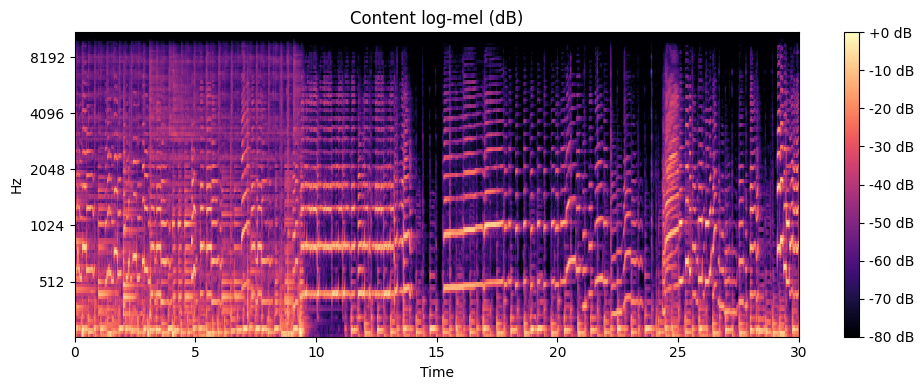

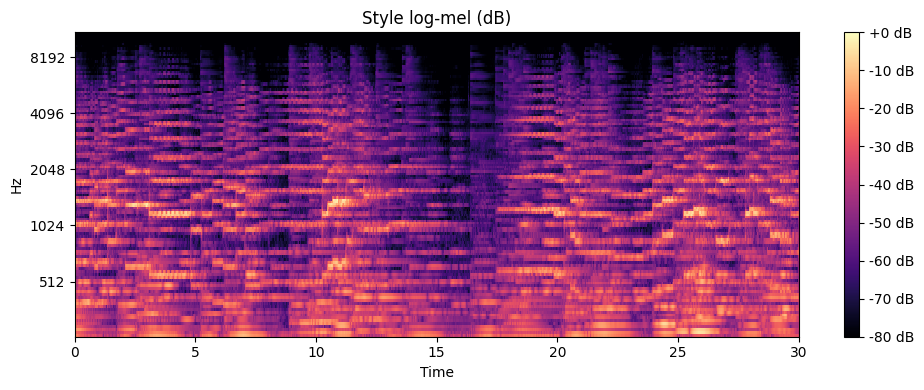

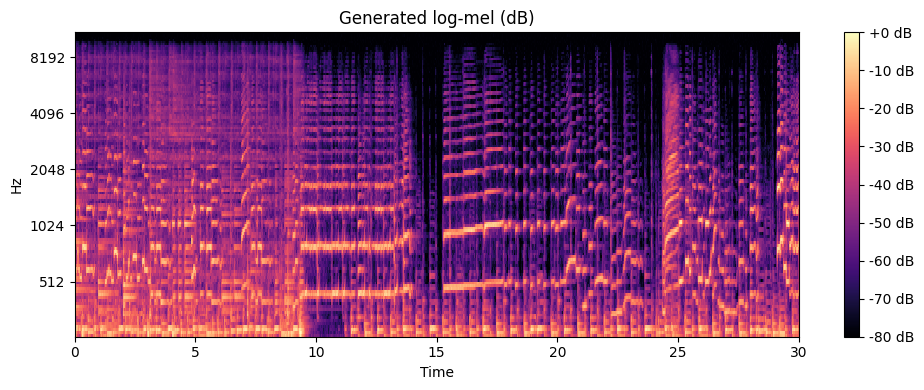

In [15]:
# Visualization helper
def plot_log_mel(log_mel_db, title="log-mel (dB)"):
    plt.figure(figsize=(10, 4))
    librosa.display.specshow(log_mel_db, sr=sr, hop_length=hop_length, x_axis='time', y_axis='mel', fmin=fmin)
    plt.title(title)
    plt.colorbar(format='%+2.0f dB')
    plt.tight_layout()
    plt.show()

# Plot examples (if variables exist)
try:
    plot_log_mel(content_log_mel, title="Content log-mel (dB)")
    plot_log_mel(style_log_mel, title="Style log-mel (dB)")
    plot_log_mel(gen_db, title="Generated log-mel (dB)")
except Exception as e:
    print("Plot skipped (missing variables).", e)


In [16]:
from IPython.display import Audio, display
sr = 22050  # same sample rate used in the notebook
display(Audio('/content/output/final_stylized.wav', rate=sr))